In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import shap
import lightgbm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score




In [56]:
data_path = "../../../datasets/titanic/train.csv"
raw_df = pd.read_csv(data_path)

df = raw_df.copy().drop(columns = ['Cabin', 'Ticket', 'Name'])

In [57]:
df = pd.get_dummies(df, columns = ['Embarked'], dtype = int)

df['Sex_Encoded'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)
df['Family'] = df['SibSp'] + df['Parch'] + 1
df['Fare'] = df['Fare'].apply(np.log1p).fillna(df.groupby('Pclass')['Fare'].transform('mean'))
df['Age'] = df['Age'].fillna(df['Age'].median())
df['IsAlone'] = (df['Family'] ==  1).astype(int)



In [58]:
data = df.drop(columns = ['PassengerId', 'SibSp', 'Parch', 'Sex'])
X = data.drop(columns = ['Survived'])
y = data['Survived']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
light_base = lightgbm.LGBMClassifier(verbose = -1)

start = time.time()
light_base.fit(X_train, y_train)
end = time.time()

predictions = np.array(light_base.predict(X_test))

print(f"Accuracy: {accuracy_score(y_test, predictions)}\nTraining Time: {end-start}")


Accuracy: 0.8212290502793296
Training Time: 0.05080580711364746


In [60]:
explainer = shap.TreeExplainer(light_base)
shap_values = explainer(X_test)



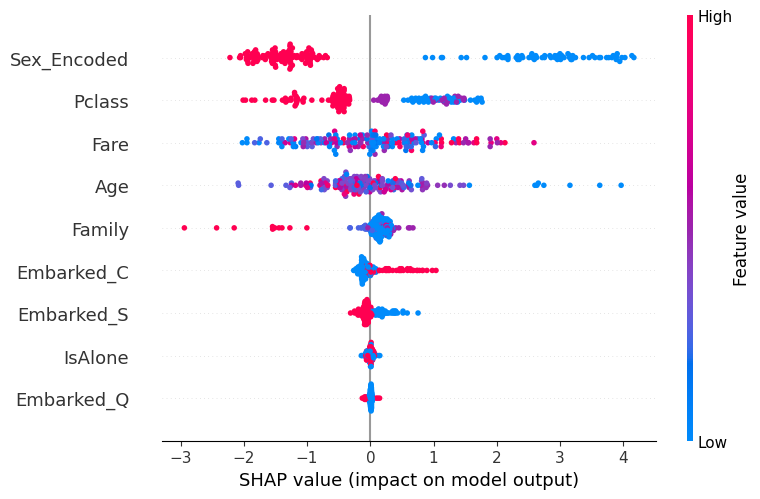

In [61]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns.to_list())

In [62]:
probabilities = np.array(light_base.predict_proba(X_test))

survived_probs = probabilities[:, 1]

results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': predictions,
    'probability': survived_probs
}, index=X_test.index) 

correct_survived = results_df[(results_df['actual']==1) & (results_df['predicted']==1)]
correct_died = results_df[(results_df['actual']==0) & (results_df['predicted']==0)]
wrong = results_df[(results_df['actual'] != results_df['predicted'])]

print(correct_survived.head(1))
print(correct_died.head(1))
print(wrong.head(1))

     actual  predicted  probability
720       1          1       0.9975
     actual  predicted  probability
439       0          0     0.186025
     actual  predicted  probability
709       1          0     0.043128


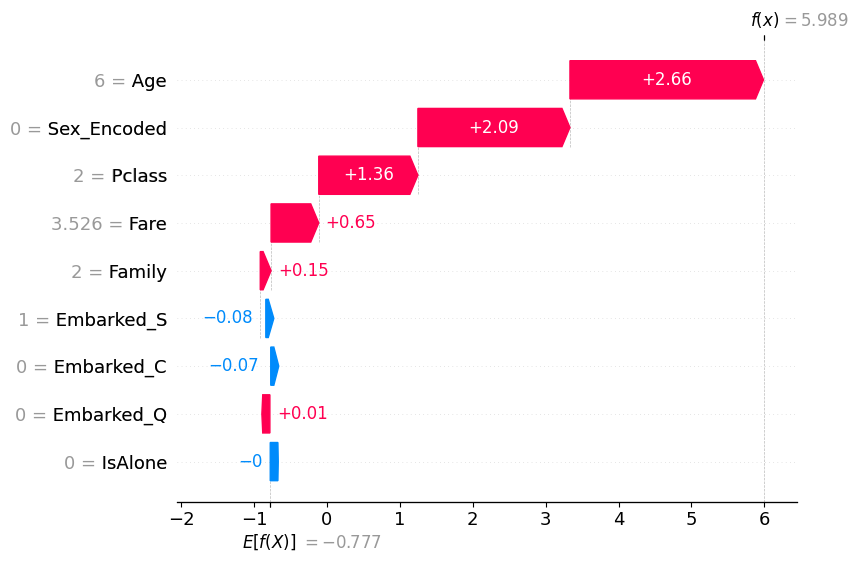

In [63]:
##Correctly Predicted Survived
shap.plots.waterfall(shap_values[3])

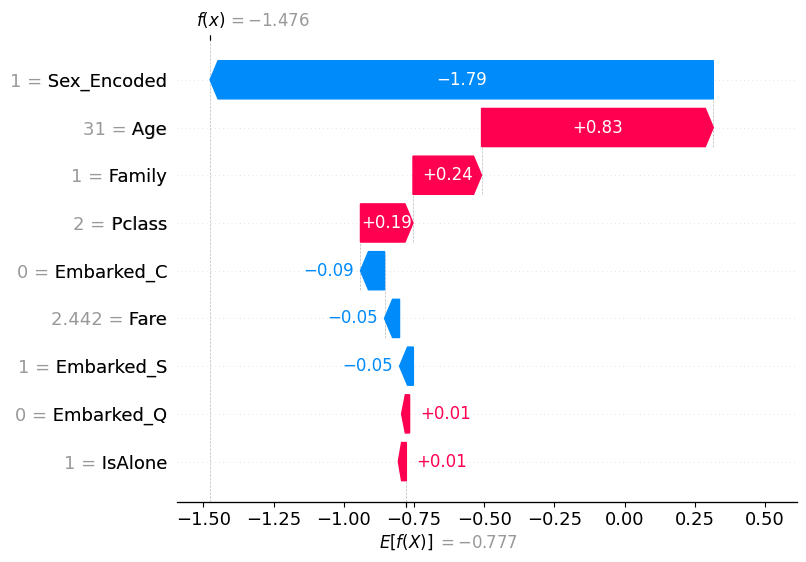

In [ ]:
##Correctly Predicted Died
shap.plots.waterfall(shap_values[1])

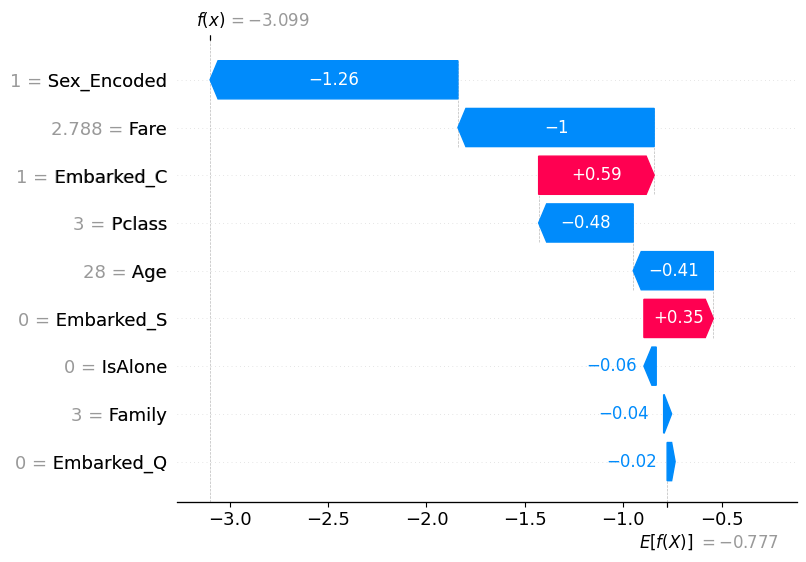

In [ ]:
##Incorrectly Predicted Survived
shap.plots.waterfall(shap_values[0])